# Python aplicado al análisis de datos

## Caso de estudio: Titanic

En este notebook trabajaremos con un dataset real para aplicar los diferentes conceptos. El objetivo es recordar cómo se explora un dataset y luego avanzar hacia limpieza, análisis, visualización e interpretación.


## Objetivos de la sesión

- recordar la exploración básica de un dataset real
- identificar problemas de calidad de datos
- realizar una limpieza simple y justificada
- aplicar análisis descriptivo
- construir visualizaciones básicas
- convertir resultados en insights


## Librerías y carga del dataset

En esta clase usaremos dos bibliotecas principales:

- **pandas**: para leer, organizar y analizar datos en forma de tabla
- **matplotlib**: para construir gráficos simples

El dataset Titanic se cargará desde una referencia pública en internet.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# URL pública del dataset Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Cargar el archivo CSV desde internet en un DataFrame
df = pd.read_csv(url)

# Mostrar las primeras filas
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Variables del dataset**

**PassengerId**
Identificador único del pasajero.

**Survived**
Indica si el pasajero sobrevivió.

0 = No sobrevivió

1 = Sobrevivió

Esta variable es binaria.

**Pclass**
Clase del pasajero.

1 = Primera clase

2 = Segunda clase

3 = Tercera clase

**Name**
Nombre completo del pasajero.

**Sex**
Sexo del pasajero.
male
female

**Age**
Edad del pasajero.
Es una variable numérica continua.

**SibSp**
Número de hermanos o cónyuges que viajaban con el pasajero.

**Parch**
Número de padres o hijos que viajaban con el pasajero.

**Ticket**
Número del ticket.

**Fare**
Precio pagado por el ticket.

**Cabin**
Cabina asignada.
Tiene muchos valores faltantes.

**Embarked**
Puerto donde abordó el Titanic.

C = Cherbourg

Q = Queenstown

S = Southampton


# Bloque 1 — Calidad y preparación de datos

Antes de limpiar o analizar, debemos comprender la estructura del dataset. En esta parte recordaremos varias instrucciones vistas en la clase anterior, pero ahora aplicadas a un caso real.


## 1.1 Primer resumen del dataset

Estas instrucciones permiten responder preguntas básicas:

- ¿cuántos registros tiene el dataset?
- ¿cuáles son sus columnas?
- ¿qué tipos de datos existen?
- ¿hay valores faltantes?


In [4]:
# Primeras filas
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Últimas filas
df.tail()


In [ ]:
# Dimensión del dataset: (filas, columnas)
df.shape


In [ ]:
# Nombres de columnas
df.columns


In [ ]:
# Estructura general y tipos de datos
df.info()


In [ ]:
# Tipo de dato de cada variable
df.dtypes


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()


In [9]:
# Cantidad de valores faltantes por columna
df.isnull().sum().sort_values(ascending=False)



,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


### Interpretación breve

Con estas instrucciones ya podemos observar que el dataset tiene variables numéricas y categóricas, y también que no todas las columnas están completas. Esto confirma por qué la exploración inicial es importante: nos ayuda a detectar problemas antes de avanzar.


### Reto 1

1. ¿Qué columna tiene más valores faltantes?
2. ¿Qué columna tiene el segundo mayor número de valores faltantes?
3. ¿Cuántas filas y cuántas columnas tiene el dataset?
4. ¿Qué variables son categóricas?


# Bloque 2 — Limpieza y transformación de datos

En datasets reales es frecuente encontrar valores faltantes, categorías incompletas o columnas muy vacías. En este bloque aplicaremos una limpieza básica, suficiente para continuar con el análisis.


## 2.1 Verificación de duplicados

Primero revisamos si existen filas duplicadas.


In [ ]:
# Contar filas duplicadas
df.duplicated().sum()


np.int64(0)

## 2.2 Tratamiento de valores nulos

En este caso realizaremos decisiones simples y explicables:

- **Age**: se completará con la mediana, porque es una variable numérica con valores faltantes
- **Embarked**: se completará con la moda, porque es una variable categórica con pocos faltantes
- **Cabin**: no se usará en el análisis principal, porque tiene demasiados valores faltantes


In [10]:
# Crear una copia para limpieza
df_clean = df.copy()

# Completar Age con la mediana
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Completar Embarked con la moda
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Verificar nuevamente valores faltantes
df_clean[['Age', 'Embarked', 'Cabin']].isnull().sum()


,0
Age,0
Embarked,0
Cabin,687


## 2.3 Crear una variable adicional

También podemos transformar los datos para enriquecer el análisis. Por ejemplo, construiremos una variable llamada **FamilySize**, que representa el tamaño del grupo familiar abordo.


In [ ]:
# FamilySize = pasajeros que viajan juntos (incluyéndose a sí mismos)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Revisar columnas relevantes
df_clean[['SibSp', 'Parch', 'FamilySize']].head()


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### Reto 2

1. ¿Por qué no sería buena idea usar la columna Cabin como base central del análisis?
2. ¿Qué diferencia existe entre completar una variable numérica con mediana y una categórica con moda?
3. Después de la limpieza, ¿qué variables seguimos considerando problemáticas si quisiéramos un análisis más avanzado?


# Bloque 3 — Análisis descriptivo de datos

Una vez que el dataset está más preparado, podemos comenzar el análisis descriptivo. En esta etapa buscamos patrones básicos.


In [ ]:
# Tasa general de supervivencia
df_clean['Survived'].mean()


np.float64(0.3838383838383838)

In [ ]:
# Supervivencia por sexo
df_clean.groupby('Sex')['Survived'].mean().sort_values(ascending=False)


,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
# Supervivencia por clase del pasajero
df_clean.groupby('Pclass')['Survived'].mean().sort_values(ascending=False)


In [ ]:
# Supervivencia por puerto de embarque
df_clean.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)


In [ ]:
# Edad promedio según supervivencia
df_clean.groupby('Survived')['Age'].mean()


### Interpretación breve

En esta fase ya no solo observamos la estructura del dataset: ahora relacionamos variables para buscar patrones. Por ejemplo, podemos comparar grupos y notar diferencias en las tasas de supervivencia.


### Reto 3

1. ¿Qué grupo tuvo mayor tasa de supervivencia: hombres o mujeres?
2. ¿Qué clase presenta la mayor tasa de supervivencia?
3. ¿Qué puerto de embarque parece estar asociado con mayor supervivencia?
4. ¿La edad promedio de quienes sobrevivieron es mayor o menor que la de quienes no sobrevivieron?


# Bloque 4 — Introducción a la visualización de datos

Los gráficos permiten observar patrones de forma más rápida. En esta parte usaremos **matplotlib**, una de las bibliotecas más comunes en Python para visualización.


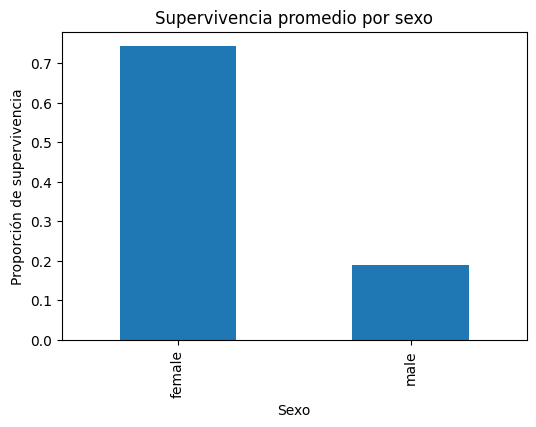

In [ ]:
# Supervivencia promedio por sexo
df_clean.groupby('Sex')['Survived'].mean().plot(kind='bar', figsize=(6,4), title='Supervivencia promedio por sexo')
plt.ylabel('Proporción de supervivencia')
plt.xlabel('Sexo')
plt.show()


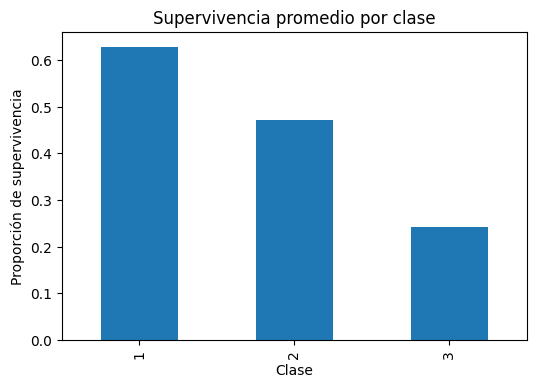

In [ ]:
# Supervivencia promedio por clase
df_clean.groupby('Pclass')['Survived'].mean().plot(kind='bar', figsize=(6,4), title='Supervivencia promedio por clase')
plt.ylabel('Proporción de supervivencia')
plt.xlabel('Clase')
plt.show()


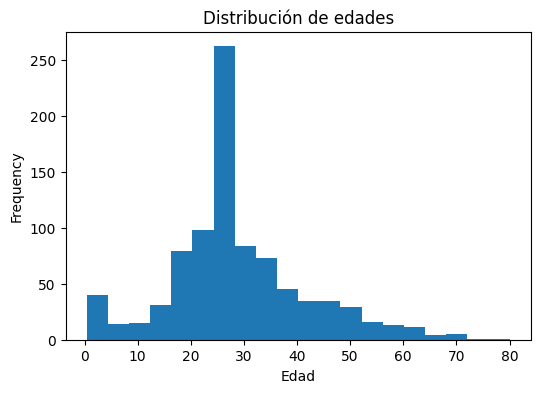

In [ ]:
# Distribución de edades
df_clean['Age'].plot(kind='hist', bins=20, figsize=(6,4), title='Distribución de edades')
plt.xlabel('Edad')
plt.show()


In [ ]:
# Distribución de tarifas pagadas
df_clean['Fare'].plot(kind='hist', bins=20, figsize=(6,4), title='Distribución de la tarifa pagada')
plt.xlabel('Fare')
plt.show()


### Reto 4

1. ¿Qué gráfico te parece más útil para explicar la supervivencia: el de sexo o el de clase?
2. ¿La distribución de edades parece uniforme o concentrada en ciertos rangos?
3. ¿Qué observas sobre la distribución de la tarifa pagada?


# Bloque 5 — Generación de insights a partir de los datos

Un insight no es solo un número o un gráfico. Es una conclusión útil que surge al interpretar varias evidencias del análisis.


In [ ]:
# Tabla cruzada de supervivencia por sexo
pd.crosstab(df_clean['Sex'], df_clean['Survived'], normalize='index')


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [ ]:
# Tarifa promedio por clase
df_clean.groupby('Pclass')['Fare'].mean()


,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


In [ ]:
# Supervivencia según tamaño de familia
pd.cut(df_clean['FamilySize'], bins=[0,1,4,20], labels=['Solo', 'Pequeña', 'Grande'])



In [ ]:
# Crear categoría de tamaño de familia y analizar supervivencia
df_clean['FamilyGroup'] = pd.cut(df_clean['FamilySize'], bins=[0,1,4,20], labels=['Solo', 'Pequeña', 'Grande'])
df_clean.groupby('FamilyGroup', observed=False)['Survived'].mean()


### Interpretación breve

En este punto ya podemos formular ideas como:

- la supervivencia no fue homogénea
- ciertas categorías muestran ventajas claras
- algunas variables parecen estar asociadas con mejores resultados

Esto es justamente lo que transforma los datos en conocimiento.


### Reto 5

Redacta dos insights analíticos breves basados en la evidencia del dataset.

Ejemplo de formato:
- Insight 1: ...
- Evidencia: ...

- Insight 2: ...
- Evidencia: ...


# Bloque 6 — Conexión con el enfoque data-driven

Una organización orientada por datos no se queda en el cálculo. Usa la evidencia para apoyar decisiones, discutir hipótesis y justificar acciones.
